In [29]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

In [30]:
load_dotenv()

model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [31]:
# Create a structured Output Schema for our LLM 
class structured_schema(BaseModel):
    sentiment : Literal['Positive', 'Negative'] = Field(description='Sentiment of Review')

In [32]:
# Create another Structured Output Schema for our LLM For Run Diagnosis
class run_diag_schema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [33]:
structured_model = model.with_structured_output(structured_schema)
structured_model2 = model.with_structured_output(run_diag_schema)

In [34]:
# Create a State
class ReviewState(TypedDict):
    review : str
    sentiment : Literal['Positive', 'Negative']
    diagnosis : dict
    response : str

In [35]:
def find_sentiment(state : ReviewState) -> ReviewState:
    prompt = f"For the following review findout the sentiment \n {state['review']}"

    senti = structured_model.invoke(prompt).sentiment

    return {'sentiment' : senti}

In [36]:
def routing_function(state : ReviewState) -> Literal['Positive_response', 'Run_Diagnosis']:
    if state['sentiment'] == 'Positive':
        return 'Positive_response' 
    else:
        return 'Run_Diagnosis'

In [37]:
def Positive_response(state: ReviewState) -> ReviewState:
    prompt = f"""Write a Warm thank You Message in response to this review: 
    \n\n \"{state['review']}\" \n
    Also, Kindly as the user to leave the feedback on our website.
    """

    response = model.invoke(prompt).content

    return {'response' : response}

In [39]:
def Run_Diagnosis(state : ReviewState) -> ReviewState:
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency."""

    result = structured_model2.invoke(prompt)

    return {'diagnosis' : result.model_dump()}

In [41]:
def negative_response(state : ReviewState) -> ReviewState:
    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant.
    The user had a issue type {diagnosis['issue_type']} issue, sounded {diagnosis['tone']} , and marked urgency {diagnosis['urgency']}"""

    response = model.invoke(prompt).content

    return {'response' : response}

In [42]:
# Create a Graph
graph = StateGraph(ReviewState)

# Create a Node
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('Positive_response', Positive_response)
graph.add_node('Run_Diagnosis', Run_Diagnosis)
graph.add_node('negative_response', negative_response)

# Create Edges

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', routing_function)

graph.add_edge('Positive_response', END)

graph.add_edge('Run_Diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

# Compile the Graph
workflow = graph.compile()

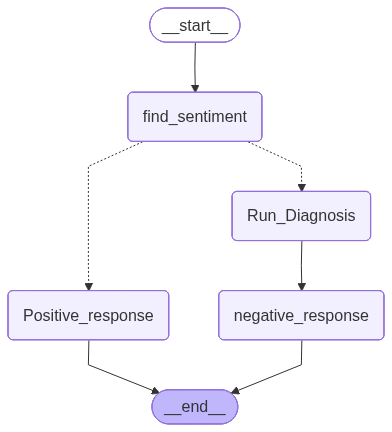

In [43]:
workflow

In [44]:

intial_state={
    'review': "I have been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I have been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'Negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': 'I understand this is a **Bug** issue and you\'re experiencing **frustration** with **high urgency**.\n\nPlease tell me more about the problem you\'re facing. The more details you can provide, the faster I can help you find a solution.\n\nTo help me understand the issue quickly, could you please tell me:\n\n*   **What is the specific problem you are encountering?** (e.g., "The login button isn\'t working," "I\'m seeing an error message when I try to save," "The application is crashing.")\n*   **When did this issue start happening?**\n*   **Are there any specific steps I can take to reproduce the bug?**\n*   **What have you tried